# Walk-Forward Evaluation - ALL FOLDS
## Comprehensive PPO Evaluation Across 50 Folds

**Date:** November 10, 2025  
**Objective:** Evaluate trained PPO agents on all 50 folds and aggregate results

---

## Contents
1. Setup & Configuration
2. Evaluate All Folds
3. Aggregate Statistics
4. Comparative Analysis
5. Performance Distribution
6. Time-Series Analysis

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# RL imports
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import torch

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Project imports
from harlf.config import TICKERS, get_fold_files, N_SPLITS
from harlf.envs.portfolio_env import PortfolioEnv
from harlf.agents.dirichlet_policy import SoftmaxActorCriticPolicy

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

✅ Imports complete
PyTorch version: 2.7.1
Device: cpu


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 1. Configuration

In [2]:
# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

# Fold range to evaluate
START_FOLD = 0
END_FOLD = 50  # Exclusive (evaluates 0-49)

# Data splits to evaluate
EVALUATE_SPLITS = ['val', 'test']  # Can also include 'train' if needed

# Model directory
MODELS_DIR = Path('../models')

# Results directory
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Reward type (should match training)
REWARD_TYPE = 'ema_sharpe'

# Seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"📊 Evaluation Configuration")
print("="*70)
print(f"Evaluating folds: {START_FOLD} to {END_FOLD-1}")
print(f"Total folds: {END_FOLD - START_FOLD}")
print(f"Data splits: {EVALUATE_SPLITS}")
print(f"Reward type: {REWARD_TYPE}")
print(f"Models directory: {MODELS_DIR.absolute()}")
print(f"Results directory: {RESULTS_DIR.absolute()}")

📊 Evaluation Configuration
Evaluating folds: 0 to 49
Total folds: 50
Data splits: ['val', 'test']
Reward type: ema_sharpe
Models directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_daily/notebooks/../models
Results directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_daily/notebooks/../results


## 2. Helper Functions

In [3]:
def make_env(fold_id, split, reward_type='ema_sharpe'):
    """Create a portfolio environment for a given fold and split."""
    env = PortfolioEnv(fold_id=fold_id, split=split, reward_type=reward_type)
    env = Monitor(env)
    return env


def evaluate_agent(agent, env, agent_name, n_episodes=1, deterministic=True):
    """
    Evaluate an agent on an environment.
    
    Returns:
        Dictionary with performance metrics and episode data
    """
    all_metrics = []
    all_returns = []
    all_weights = []
    all_values = []
    
    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        truncated = False
        
        episode_returns = []
        episode_weights = []
        episode_values = [info['portfolio_value']]
        
        while not (done or truncated):
            action, _states = agent.predict(obs, deterministic=deterministic)
            obs, reward, done, truncated, info = env.step(action)
            
            episode_returns.append(info['portfolio_return'])
            episode_weights.append(info['weights'])
            episode_values.append(info['portfolio_value'])
        
        # Get episode metrics from unwrapped env
        unwrapped_env = env.unwrapped if hasattr(env, 'unwrapped') else env
        if hasattr(unwrapped_env, 'get_episode_metrics'):
            metrics = unwrapped_env.get_episode_metrics()
            all_metrics.append(metrics)
        
        all_returns.append(episode_returns)
        all_weights.append(episode_weights)
        all_values.append(episode_values)
    
    # Average metrics across episodes
    if all_metrics:
        avg_metrics = {k: np.mean([m[k] for m in all_metrics]) for k in all_metrics[0].keys()}
    else:
        avg_metrics = {}
    
    return {
        'agent_name': agent_name,
        'metrics': avg_metrics,
        'returns': all_returns[0] if n_episodes == 1 else all_returns,
        'weights': all_weights[0] if n_episodes == 1 else all_weights,
        'values': all_values[0] if n_episodes == 1 else all_values,
    }

print("✅ Helper functions defined")

✅ Helper functions defined


## 3. Baseline Strategies

In [4]:
class EqualWeightStrategy:
    """Equal weight (1/N) strategy."""
    
    def __init__(self, n_assets=7):
        self.n_assets = n_assets
        self.weights = np.ones(n_assets) / n_assets
    
    def predict(self, observation, deterministic=True):
        """Predict action."""
        return self.weights, None


class RandomStrategy:
    """Random portfolio weights."""
    
    def __init__(self, n_assets=7, seed=42):
        self.n_assets = n_assets
        self.rng = np.random.RandomState(seed)
    
    def predict(self, observation, deterministic=True):
        """Predict action."""
        weights = self.rng.dirichlet(np.ones(self.n_assets))
        return weights, None


class MomentumStrategy:
    """Simple momentum: allocate to assets with positive 21-day returns."""
    
    def __init__(self, n_assets=7):
        self.n_assets = n_assets
    
    def predict(self, observation, deterministic=True):
        """Predict action."""
        # Extract return_21d for each asset (feature index 1)
        n_features = len(observation) // self.n_assets
        returns = [observation[i * n_features + 1] for i in range(self.n_assets)]
        
        # Allocate to positive momentum assets
        positive_returns = np.array([max(r, 0) for r in returns])
        
        if positive_returns.sum() > 0:
            weights = positive_returns / positive_returns.sum()
        else:
            weights = np.ones(self.n_assets) / self.n_assets
        
        return weights, None

print("✅ Baseline strategies defined")

✅ Baseline strategies defined


## 4. Evaluate All Folds

Loop through all folds and evaluate PPO + baselines on each fold.

In [5]:
# Initialize baseline strategies (same across all folds)
baselines = {
    'Equal Weight': EqualWeightStrategy(),
    'Random': RandomStrategy(seed=SEED),
    'Momentum': MomentumStrategy(),
}

# Store all results
all_results = []

print("\n" + "="*70)
print("🔍 EVALUATING ALL FOLDS")
print("="*70)

# Loop through all folds
for fold_id in tqdm(range(START_FOLD, END_FOLD), desc="Evaluating folds"):
    fold_results = {
        'fold_id': fold_id,
    }
    
    # Check if PPO model exists
    model_path = MODELS_DIR / f'fold_{fold_id}' / f'ppo_fold_{fold_id}_final.zip'
    
    if not model_path.exists():
        print(f"\n⚠️  Fold {fold_id}: Model not found at {model_path}")
        fold_results['status'] = 'model_not_found'
        all_results.append(fold_results)
        continue
    
    try:
        # Load PPO model
        ppo_model = PPO.load(str(model_path))
        
        # Evaluate on each split
        for split in EVALUATE_SPLITS:
            # Create environment
            env = make_env(fold_id, split, REWARD_TYPE)
            
            # Evaluate PPO
            ppo_result = evaluate_agent(ppo_model, env, 'PPO', n_episodes=1, deterministic=True)
            ppo_metrics = ppo_result['metrics']
            
            # Store PPO metrics
            for metric_name, value in ppo_metrics.items():
                fold_results[f'ppo_{split}_{metric_name}'] = value
            
            # Evaluate baselines
            for baseline_name, baseline_agent in baselines.items():
                baseline_result = evaluate_agent(baseline_agent, env, baseline_name, n_episodes=1, deterministic=True)
                baseline_metrics = baseline_result['metrics']
                
                # Store baseline metrics
                for metric_name, value in baseline_metrics.items():
                    fold_results[f'{baseline_name.lower().replace(" ", "_")}_{split}_{metric_name}'] = value
            
            # Clean up environment
            env.close()
            del env
        
        fold_results['status'] = 'success'
        
    except Exception as e:
        print(f"\n❌ Fold {fold_id}: Error during evaluation: {e}")
        fold_results['status'] = 'error'
        fold_results['error_message'] = str(e)
    
    finally:
        # Clean up model
        if 'ppo_model' in locals():
            del ppo_model
        
        # Force garbage collection
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    all_results.append(fold_results)

print("\n✅ Evaluation complete!")

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

# Save results
results_file = RESULTS_DIR / 'all_folds_evaluation.csv'
results_df.to_csv(results_file, index=False)
print(f"\n💾 Results saved to: {results_file}")

# Print summary
n_success = (results_df['status'] == 'success').sum()
n_failed = (results_df['status'] == 'error').sum()
n_missing = (results_df['status'] == 'model_not_found').sum()

print(f"\n📊 Evaluation Summary:")
print(f"   ✅ Successfully evaluated: {n_success}/{END_FOLD-START_FOLD}")
print(f"   ❌ Failed: {n_failed}")
print(f"   ⚠️  Models not found: {n_missing}")


🔍 EVALUATING ALL FOLDS


Evaluating folds:   0%|          | 0/50 [00:00<?, ?it/s]


❌ Fold 0: Error during evaluation: No module named 'agents'


Evaluating folds: 100%|██████████| 50/50 [00:21<00:00,  2.37it/s]


⚠️  Fold 42: Model not found at ../models/fold_42/ppo_fold_42_final.zip

⚠️  Fold 43: Model not found at ../models/fold_43/ppo_fold_43_final.zip

⚠️  Fold 44: Model not found at ../models/fold_44/ppo_fold_44_final.zip

⚠️  Fold 45: Model not found at ../models/fold_45/ppo_fold_45_final.zip

⚠️  Fold 46: Model not found at ../models/fold_46/ppo_fold_46_final.zip

⚠️  Fold 47: Model not found at ../models/fold_47/ppo_fold_47_final.zip

⚠️  Fold 48: Model not found at ../models/fold_48/ppo_fold_48_final.zip

⚠️  Fold 49: Model not found at ../models/fold_49/ppo_fold_49_final.zip

✅ Evaluation complete!

💾 Results saved to: ../results/all_folds_evaluation.csv

📊 Evaluation Summary:
   ✅ Successfully evaluated: 41/50
   ❌ Failed: 1
   ⚠️  Models not found: 8


## 5. Aggregate Statistics

Calculate aggregate performance metrics across all folds.

In [12]:
# Filter successful evaluations
success_df = results_df[results_df['status'] == 'success'].copy()

print(f"\n📊 AGGREGATE STATISTICS ({len(success_df)} successful folds)")
print("="*100)

# Define agents and metrics to aggregate
agents = ['ppo', 'equal_weight', 'random', 'momentum']
agent_display_names = {
    'ppo': 'PPO',
    'equal_weight': 'Equal Weight',
    'random': 'Random',
    'momentum': 'Momentum'
}

key_metrics = ['sharpe_ratio', 'total_return', 'max_drawdown', 'volatility', 'sortino_ratio', 'mean_turnover']

# Aggregate for each split
for split in EVALUATE_SPLITS:
    print(f"\n{'='*100}")
    print(f"{split.upper()} SET AGGREGATES")
    print(f"{'='*100}\n")
    
    agg_data = []
    
    for agent in agents:
        agent_stats = {'Agent': agent_display_names[agent]}
        
        for metric in key_metrics:
            col_name = f'{agent}_{split}_{metric}'
            
            if col_name in success_df.columns:
                values = success_df[col_name].dropna()
                
                agent_stats[f'{metric}_mean'] = values.mean()
                agent_stats[f'{metric}_std'] = values.std()
                agent_stats[f'{metric}_median'] = values.median()
                agent_stats[f'{metric}_min'] = values.min()
                agent_stats[f'{metric}_max'] = values.max()
        
        agg_data.append(agent_stats)
    
    agg_df = pd.DataFrame(agg_data).set_index('Agent')
    
    # Display key metrics: mean ± std
    display_data = []
    for agent in agents:
        row = {'Agent': agent_display_names[agent]}
        for metric in key_metrics:
            mean_col = f'{metric}_mean'
            std_col = f'{metric}_std'
            if mean_col in agg_df.columns:
                mean_val = agg_df.loc[agent_display_names[agent], mean_col]
                std_val = agg_df.loc[agent_display_names[agent], std_col]
                row[metric] = f"{mean_val:.4f} ± {std_val:.4f}"
        display_data.append(row)
    
    display_df = pd.DataFrame(display_data).set_index('Agent')
    print(display_df.to_string())
    print("\n")
    
    # Save aggregate stats
    agg_file = RESULTS_DIR / f'aggregate_stats_{split}.csv'
    agg_df.to_csv(agg_file)
    print(f"💾 Saved to: {agg_file}")


📊 AGGREGATE STATISTICS (41 successful folds)

VAL SET AGGREGATES

                 sharpe_ratio              total_return     max_drawdown       volatility     sortino_ratio    mean_turnover
Agent                                                                                                                       
PPO           7.4785 ± 2.8798  42749.6641 ± 141355.7583  0.8514 ± 0.1226  2.6655 ± 0.6283  13.2757 ± 5.9895  0.3326 ± 0.0239
Equal Weight  0.5310 ± 2.3636          3.0651 ± 14.0955  0.9528 ± 0.0546  2.3630 ± 0.5590   0.7344 ± 3.4228  0.0000 ± 0.0000
Random        0.3542 ± 2.2632          2.0954 ± 11.0031  0.9602 ± 0.0412  2.4904 ± 0.5505   0.5025 ± 3.3557  0.9181 ± 0.0270
Momentum      5.4373 ± 2.6455  30851.1439 ± 183028.5947  0.9082 ± 0.1021  3.0642 ± 0.6166   8.6397 ± 4.4584  0.3437 ± 0.0595


💾 Saved to: ../results/aggregate_stats_val.csv

TEST SET AGGREGATES

                  sharpe_ratio     total_return     max_drawdown       volatility                  sortino_ratio

## 6. Performance Distribution Analysis

Visualize the distribution of performance metrics across folds.

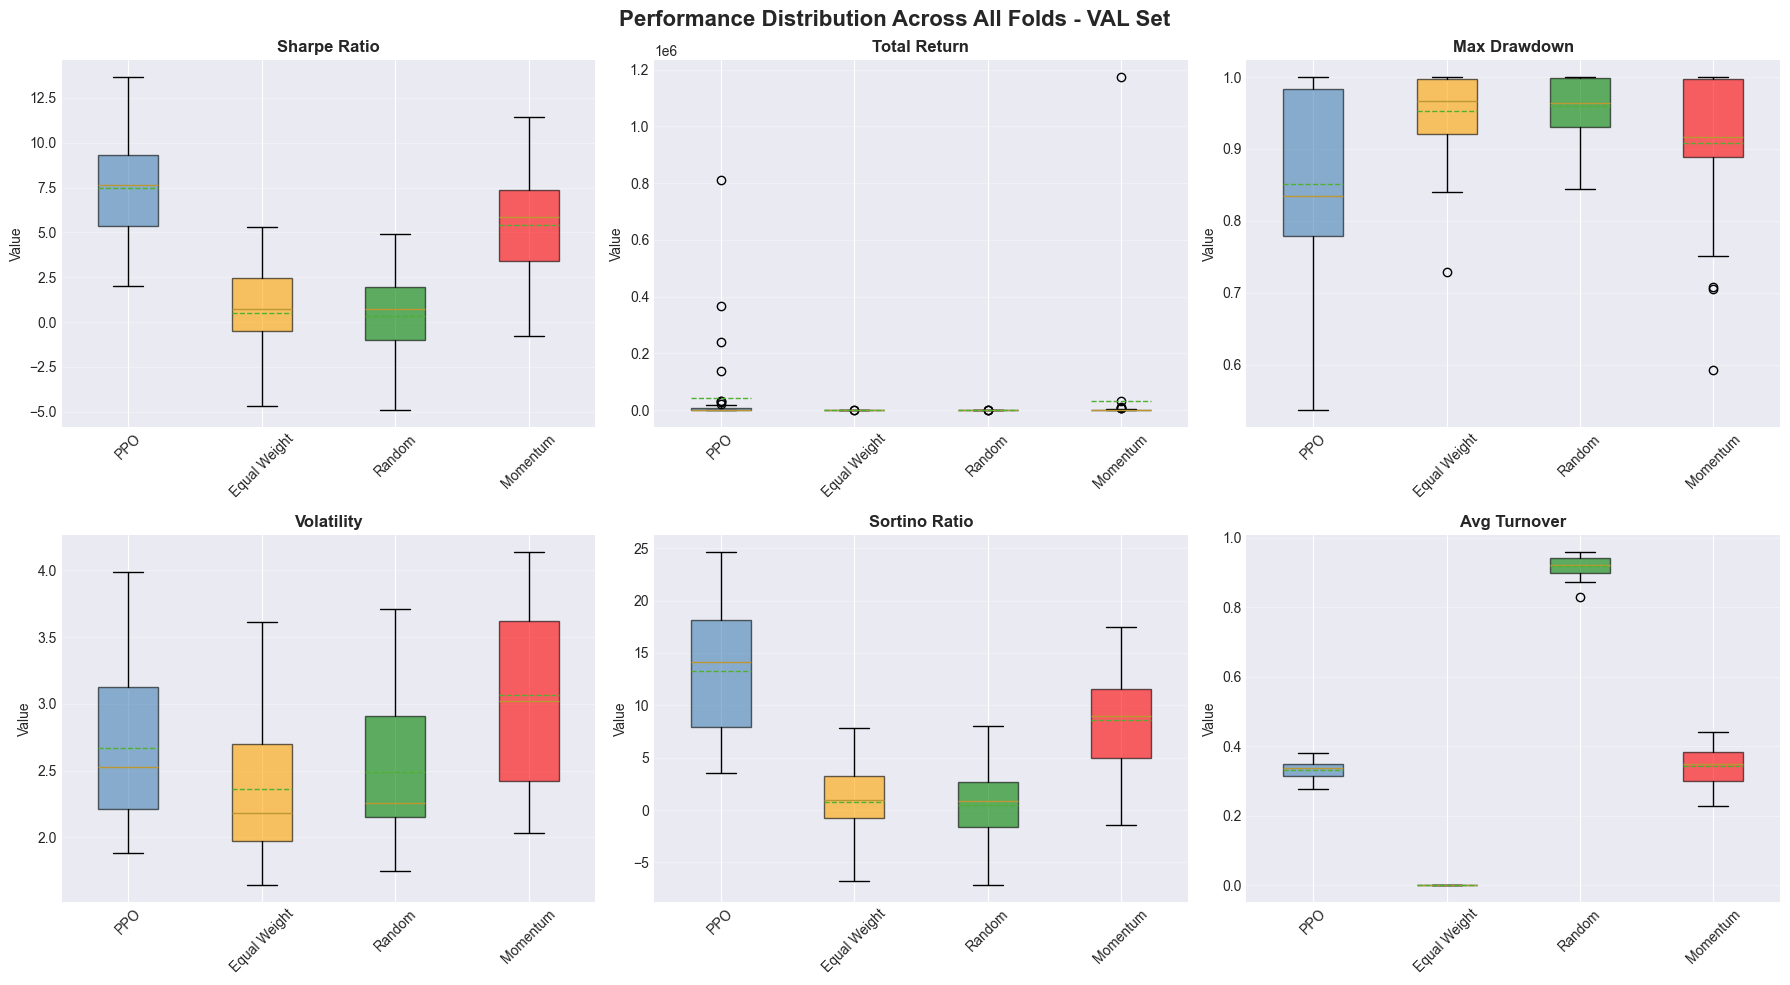

💾 Plot saved to: ../results/performance_distribution_val.png


In [7]:
# Visualizations for validation set
split = 'val'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = ['sharpe_ratio', 'total_return', 'max_drawdown', 'volatility', 'sortino_ratio', 'mean_turnover']
metric_labels = ['Sharpe Ratio', 'Total Return', 'Max Drawdown', 'Volatility', 'Sortino Ratio', 'Avg Turnover']

for i, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[i]
    
    # Collect data for boxplot
    data_to_plot = []
    labels_to_plot = []
    
    for agent in agents:
        col_name = f'{agent}_{split}_{metric}'
        if col_name in success_df.columns:
            values = success_df[col_name].dropna()
            data_to_plot.append(values)
            labels_to_plot.append(agent_display_names[agent])
    
    # Create boxplot
    bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True, 
                     showmeans=True, meanline=True)
    
    # Color boxes
    colors = ['steelblue', 'orange', 'green', 'red']
    for patch, color in zip(bp['boxes'], colors[:len(data_to_plot)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Performance Distribution Across All Folds - {split.upper()} Set', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'performance_distribution_{split}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Plot saved to: {RESULTS_DIR / f'performance_distribution_{split}.png'}")

## 7. Win Rate Analysis

Calculate how often PPO beats each baseline.

In [8]:
print("\n📊 WIN RATE ANALYSIS")
print("="*70)

for split in EVALUATE_SPLITS:
    print(f"\n{split.upper()} SET:")
    print("-"*70)
    
    win_rates = {}
    
    for metric in ['sharpe_ratio', 'total_return', 'sortino_ratio']:
        ppo_col = f'ppo_{split}_{metric}'
        
        if ppo_col not in success_df.columns:
            continue
        
        print(f"\n{metric.upper().replace('_', ' ')}:")
        
        for agent in ['equal_weight', 'random', 'momentum']:
            baseline_col = f'{agent}_{split}_{metric}'
            
            if baseline_col in success_df.columns:
                # Calculate win rate
                wins = (success_df[ppo_col] > success_df[baseline_col]).sum()
                total = len(success_df)
                win_rate = (wins / total) * 100
                
                # Calculate average difference
                avg_diff = (success_df[ppo_col] - success_df[baseline_col]).mean()
                
                print(f"  PPO vs {agent_display_names[agent]:15s}: {win_rate:5.1f}% ({wins}/{total}) | Avg Diff: {avg_diff:+.4f}")
                
                win_rates[f'{metric}_{agent}'] = win_rate

print("\n" + "="*70)


📊 WIN RATE ANALYSIS

VAL SET:
----------------------------------------------------------------------

SHARPE RATIO:
  PPO vs Equal Weight   : 100.0% (41/41) | Avg Diff: +6.9475
  PPO vs Random         : 100.0% (41/41) | Avg Diff: +7.1243
  PPO vs Momentum       :  95.1% (39/41) | Avg Diff: +2.0412

TOTAL RETURN:
  PPO vs Equal Weight   : 100.0% (41/41) | Avg Diff: +42746.5990
  PPO vs Random         : 100.0% (41/41) | Avg Diff: +42747.5687
  PPO vs Momentum       :  92.7% (38/41) | Avg Diff: +11898.5202

SORTINO RATIO:
  PPO vs Equal Weight   : 100.0% (41/41) | Avg Diff: +12.5413
  PPO vs Random         : 100.0% (41/41) | Avg Diff: +12.7732
  PPO vs Momentum       :  95.1% (39/41) | Avg Diff: +4.6361

TEST SET:
----------------------------------------------------------------------

SHARPE RATIO:
  PPO vs Equal Weight   : 100.0% (41/41) | Avg Diff: +8.5366
  PPO vs Random         : 100.0% (41/41) | Avg Diff: +8.8004
  PPO vs Momentum       :  80.5% (33/41) | Avg Diff: +2.6333

TOTAL RE

## 8. Time-Series Performance

Plot performance metrics over time (across folds).

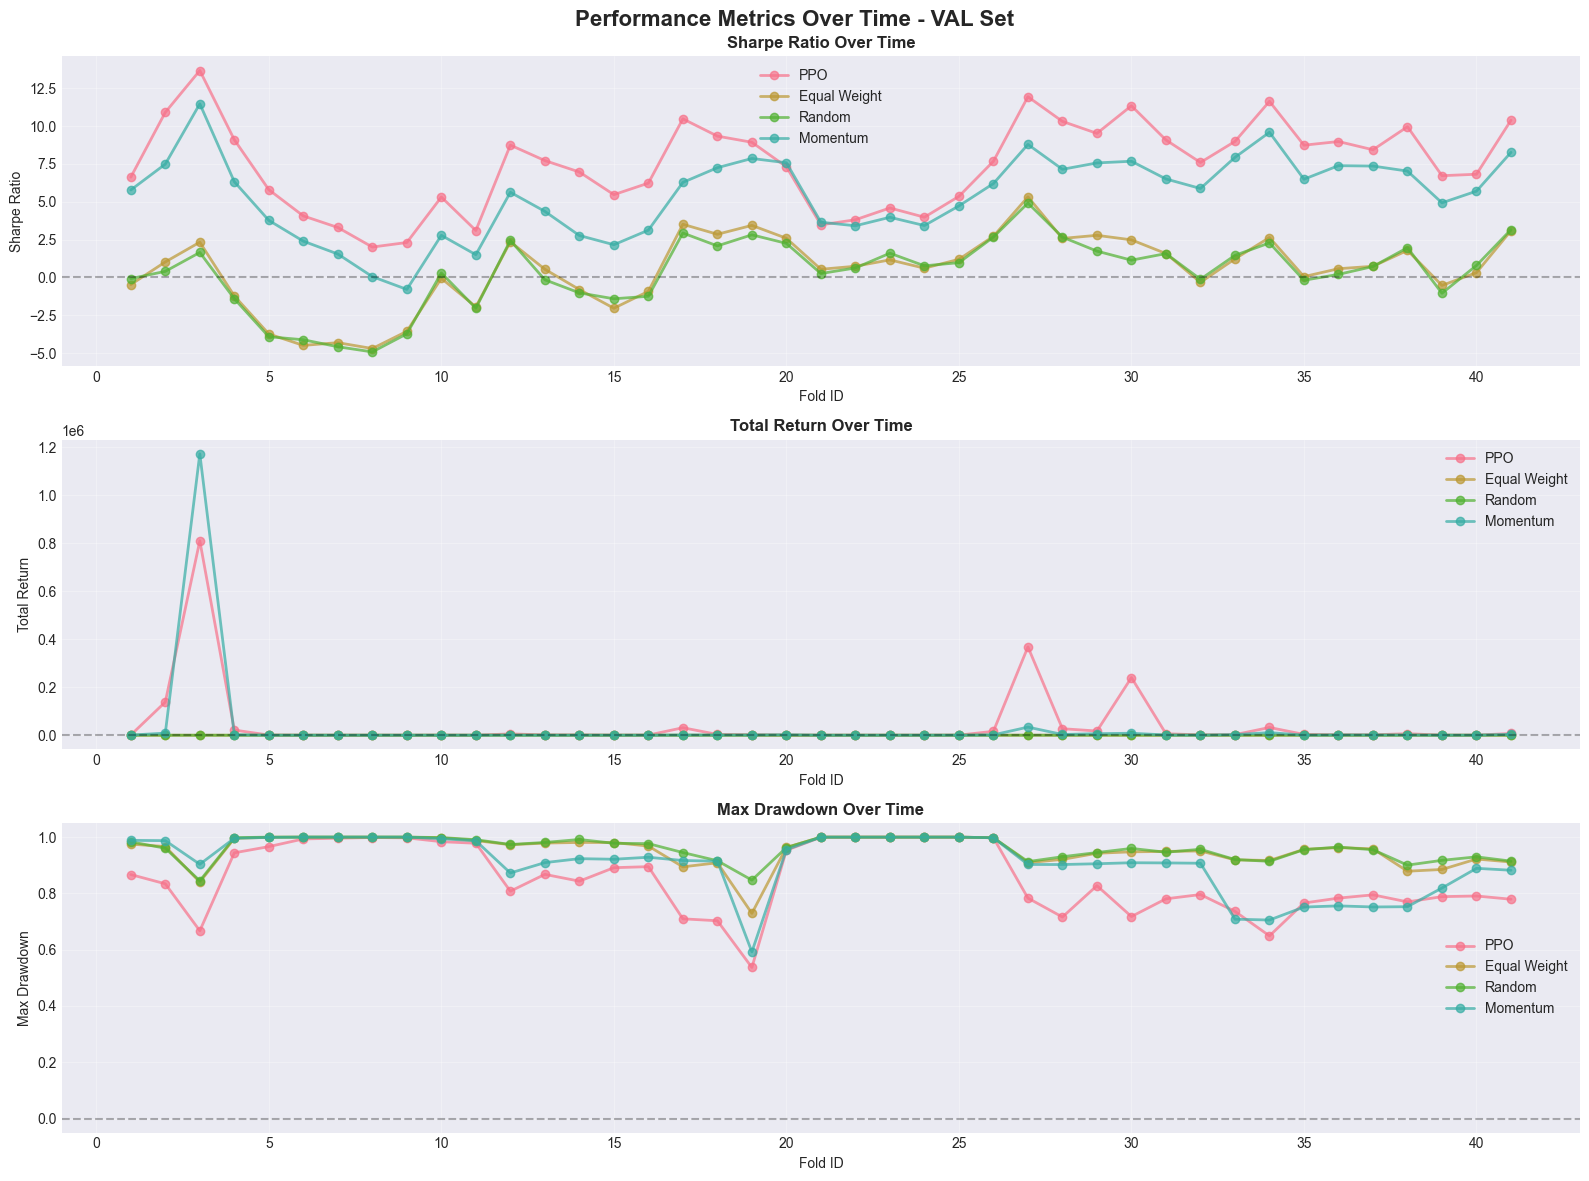

💾 Plot saved to: ../results/performance_over_time_val.png


In [9]:
split = 'val'

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

metrics_to_plot = ['sharpe_ratio', 'total_return', 'max_drawdown']
metric_labels = ['Sharpe Ratio', 'Total Return', 'Max Drawdown']

for i, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[i]
    
    for agent in agents:
        col_name = f'{agent}_{split}_{metric}'
        if col_name in success_df.columns:
            ax.plot(success_df['fold_id'], success_df[col_name], 
                   label=agent_display_names[agent], marker='o', alpha=0.7, linewidth=2)
    
    ax.set_title(f'{label} Over Time', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold ID', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.suptitle(f'Performance Metrics Over Time - {split.upper()} Set', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'performance_over_time_{split}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Plot saved to: {RESULTS_DIR / f'performance_over_time_{split}.png'}")

## 9. Statistical Tests

Perform paired t-tests to check if PPO's outperformance is statistically significant.

In [10]:
from scipy import stats

print("\n📊 STATISTICAL SIGNIFICANCE TESTS (Paired t-test)")
print("="*70)

for split in EVALUATE_SPLITS:
    print(f"\n{split.upper()} SET:")
    print("-"*70)
    
    for metric in ['sharpe_ratio', 'total_return', 'sortino_ratio']:
        ppo_col = f'ppo_{split}_{metric}'
        
        if ppo_col not in success_df.columns:
            continue
        
        print(f"\n{metric.upper().replace('_', ' ')}:")
        
        ppo_values = success_df[ppo_col].dropna()
        
        for agent in ['equal_weight', 'random', 'momentum']:
            baseline_col = f'{agent}_{split}_{metric}'
            
            if baseline_col in success_df.columns:
                baseline_values = success_df[baseline_col].dropna()
                
                # Ensure same length
                min_len = min(len(ppo_values), len(baseline_values))
                ppo_test = ppo_values.iloc[:min_len]
                baseline_test = baseline_values.iloc[:min_len]
                
                # Paired t-test
                t_stat, p_value = stats.ttest_rel(ppo_test, baseline_test)
                
                # Determine significance
                if p_value < 0.001:
                    sig = "***"
                elif p_value < 0.01:
                    sig = "**"
                elif p_value < 0.05:
                    sig = "*"
                else:
                    sig = "n.s."
                
                mean_diff = (ppo_test - baseline_test).mean()
                
                print(f"  PPO vs {agent_display_names[agent]:15s}: "
                      f"t={t_stat:+6.3f}, p={p_value:.4f} {sig:4s} | "
                      f"Mean Diff: {mean_diff:+.4f}")

print("\n" + "="*70)
print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, n.s. = not significant")


📊 STATISTICAL SIGNIFICANCE TESTS (Paired t-test)

VAL SET:
----------------------------------------------------------------------

SHARPE RATIO:
  PPO vs Equal Weight   : t=+22.893, p=0.0000 ***  | Mean Diff: +6.9475
  PPO vs Random         : t=+21.984, p=0.0000 ***  | Mean Diff: +7.1243
  PPO vs Momentum       : t=+11.647, p=0.0000 ***  | Mean Diff: +2.0412

TOTAL RETURN:
  PPO vs Equal Weight   : t=+1.936, p=0.0599 n.s. | Mean Diff: +42746.5990
  PPO vs Random         : t=+1.936, p=0.0599 n.s. | Mean Diff: +42747.5687
  PPO vs Momentum       : t=+0.864, p=0.3929 n.s. | Mean Diff: +11898.5202

SORTINO RATIO:
  PPO vs Equal Weight   : t=+16.908, p=0.0000 ***  | Mean Diff: +12.5413
  PPO vs Random         : t=+16.548, p=0.0000 ***  | Mean Diff: +12.7732
  PPO vs Momentum       : t=+10.118, p=0.0000 ***  | Mean Diff: +4.6361

TEST SET:
----------------------------------------------------------------------

SHARPE RATIO:
  PPO vs Equal Weight   : t=+13.752, p=0.0000 ***  | Mean Diff: +8.

## 10. Summary Report

Generate a final summary report.

In [11]:
print("\n" + "="*100)
print("📊 WALK-FORWARD EVALUATION SUMMARY")
print("="*100)

print(f"\nTotal folds evaluated: {len(success_df)}/{END_FOLD-START_FOLD}")
print(f"Data splits: {', '.join(EVALUATE_SPLITS)}")
print(f"\nResults saved to: {RESULTS_DIR.absolute()}")
print(f"  - all_folds_evaluation.csv: Raw results for all folds")
for split in EVALUATE_SPLITS:
    print(f"  - aggregate_stats_{split}.csv: Aggregate statistics for {split} set")
    print(f"  - performance_distribution_{split}.png: Distribution plots")
    print(f"  - performance_over_time_{split}.png: Time-series plots")

print("\n" + "="*100)
print("✅ EVALUATION COMPLETE")
print("="*100)


📊 WALK-FORWARD EVALUATION SUMMARY

Total folds evaluated: 41/50
Data splits: val, test

Results saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_daily/notebooks/../results
  - all_folds_evaluation.csv: Raw results for all folds
  - aggregate_stats_val.csv: Aggregate statistics for val set
  - performance_distribution_val.png: Distribution plots
  - performance_over_time_val.png: Time-series plots
  - aggregate_stats_test.csv: Aggregate statistics for test set
  - performance_distribution_test.png: Distribution plots
  - performance_over_time_test.png: Time-series plots

✅ EVALUATION COMPLETE
